%% [markdown]
# 02 — Analyse Exploratoire des Données (EDA)

**Phase 2 — Livrable 1**

Exploration complète du dataset GitHub Repository Activity :
1. Analyse univariée (numériques, catégorielles, binaires)
2. Analyse bivariée (features × is_inactive)
3. Matrice de corrélation
4. Analyse du déséquilibre des classes
5. Synthèse des observations

%% [markdown]
## Setup et chargement des données

In [1]:
# %%
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Configuration graphique
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

In [3]:
# %%
# Chargement du dataset
df = pd.read_csv('../dataset.csv')
print(f"Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\nInfo :")
df.info()

Dimensions : 15000 lignes × 22 colonnes

Info :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   full_name                 15000 non-null  object 
 1   collected_at              15000 non-null  object 
 2   stars                     15000 non-null  int64  
 3   forks                     15000 non-null  int64  
 4   open_issues               15000 non-null  int64  
 5   watchers                  15000 non-null  int64  
 6   size_kb                   15000 non-null  int64  
 7   repo_age_days             15000 non-null  int64  
 8   days_since_last_push      15000 non-null  int64  
 9   contributor_count         15000 non-null  int64  
 10  avg_issue_response_hours  15000 non-null  float64
 11  engagement_rate           15000 non-null  float64
 12  stars_forks_ratio         15000 non-null  float64
 13  language     

In [4]:
# %%
# Aperçu des premières lignes
df.head()

,full_name,collected_at,stars,forks,open_issues,watchers,size_kb,repo_age_days,days_since_last_push,contributor_count,...,stars_forks_ratio,language,license,has_description,has_homepage,has_wiki,has_projects,is_fork,archived,is_inactive
0,gsp8181/thai-number-flashcards,2026-05-14T22:01:23.267879+00:00,5,0,0,5,135,156,147,2,...,5.00,JavaScript,MIT License,0,0,0,1,0,0,0
1,openMF/mifos-workflow,2026-05-15T02:03:38.911022+00:00,5,9,9,5,1149,367,2,4,...,0.56,Java,Mozilla Public License 2.0,0,0,1,1,0,0,0
2,Obsidian-OS/installer,2026-05-15T02:33:24.080292+00:00,5,0,1,5,165,268,112,2,...,5.00,C++,MIT License,1,0,0,0,0,0,0
3,enovella/bhd-ebook-exercises,2026-05-14T20:57:03.965027+00:00,5,2,0,5,36235,3188,2676,1,...,2.50,C,NaN,1,0,1,1,0,0,1
4,makoConstruct/jostletree.rs,2026-05-14T20:39:11.957857+00:00,5,0,1,5,51,4258,375,2,...,5.00,Rust,NaN,1,0,1,1,0,0,1


In [5]:
# %%
# Définition des groupes de variables
numeric_cols = ['stars', 'forks', 'open_issues', 'watchers', 'size_kb',
                'repo_age_days', 'days_since_last_push', 'contributor_count',
                'avg_issue_response_hours', 'engagement_rate', 'stars_forks_ratio']

In [6]:
cat_cols = ['language', 'license']

In [7]:
binary_cols = ['has_description', 'has_homepage', 'has_wiki', 'has_projects',
               'is_fork', 'archived']

In [8]:
target = 'is_inactive'

%% [markdown]
---
## 1. Exploration univariée — Variables numériques

Pour chaque variable numérique : histogramme, boxplot, et statistiques descriptives
(mean, median, std, Q1, Q3, min, max).

In [9]:
# %%
# Tableau récapitulatif des statistiques descriptives
desc = df[numeric_cols].describe().T
desc['median'] = df[numeric_cols].median()
desc['Q1'] = df[numeric_cols].quantile(0.25)
desc['Q3'] = df[numeric_cols].quantile(0.75)
desc = desc[['count', 'mean', 'std', 'min', 'Q1', 'median', 'Q3', 'max']]
desc.round(2)

,count,mean,std,min,Q1,median,Q3,max
stars,15000.0,7.71,4.42,4.0,5.0,5.00,14.00,16.00
forks,15000.0,3.68,41.84,0.0,0.0,1.00,3.00,4802.00
open_issues,15000.0,4.02,43.08,0.0,0.0,0.00,2.00,4365.00
watchers,15000.0,7.71,4.42,4.0,5.0,5.00,14.00,16.00
size_kb,15000.0,27360.98,237035.71,0.0,140.0,721.00,5529.25,18648336.00
repo_age_days,15000.0,1486.29,1512.96,30.0,191.0,871.00,2537.00,6656.00
days_since_last_push,15000.0,485.15,1155.61,0.0,15.0,62.00,138.00,6623.00
contributor_count,15000.0,5.12,11.47,-1.0,1.0,2.00,4.00,100.00
avg_issue_response_hours,15000.0,1185.80,5212.53,-1.0,-1.0,-1.00,36.00,102575.39
engagement_rate,15000.0,0.04,0.08,0.0,0.0,0.01,0.04,5.86


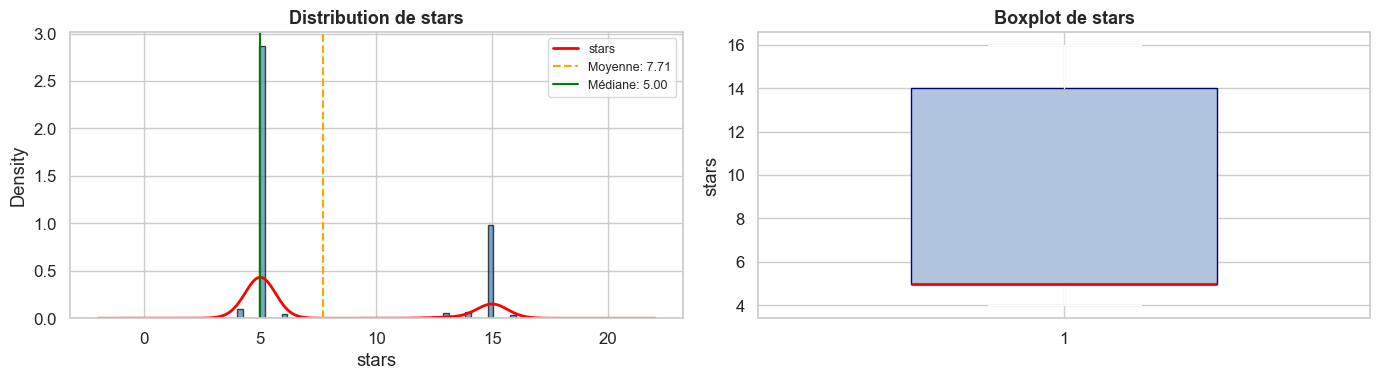

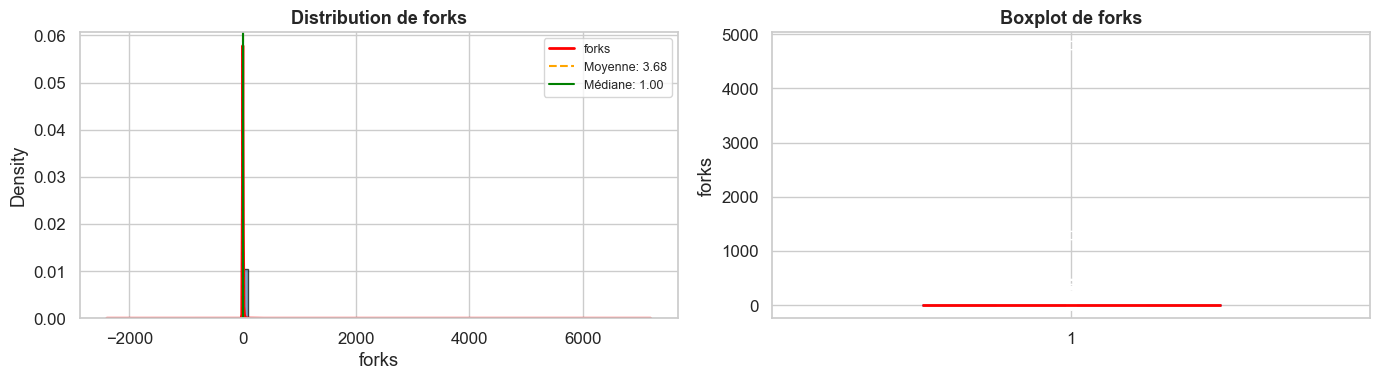

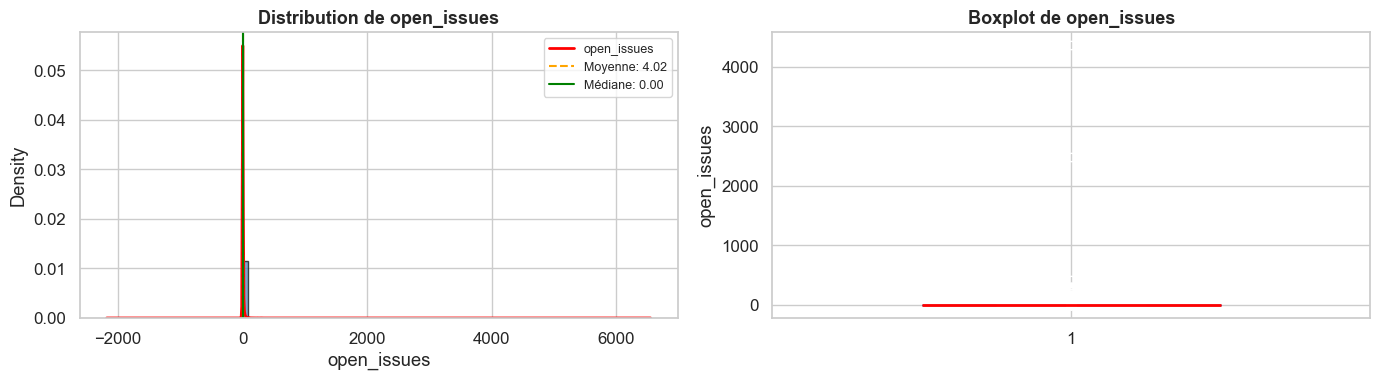

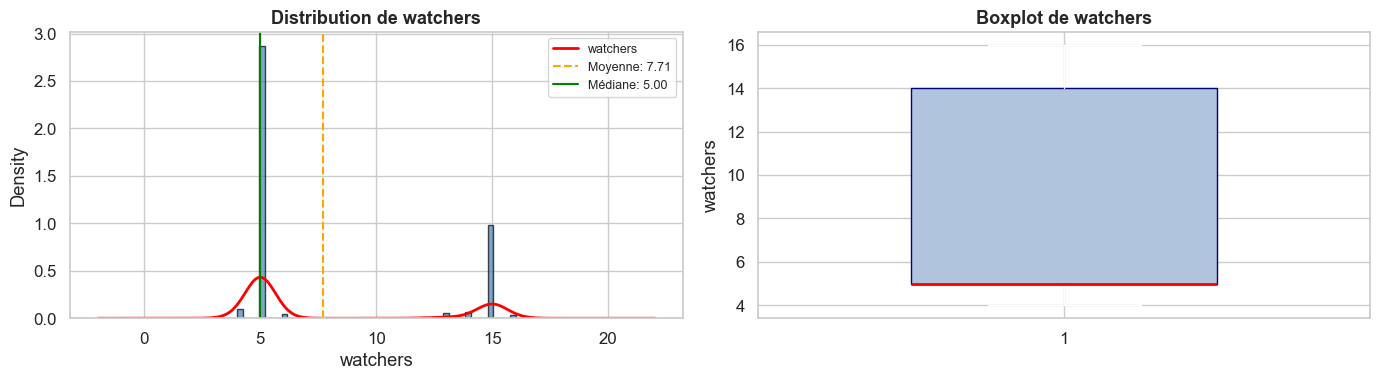

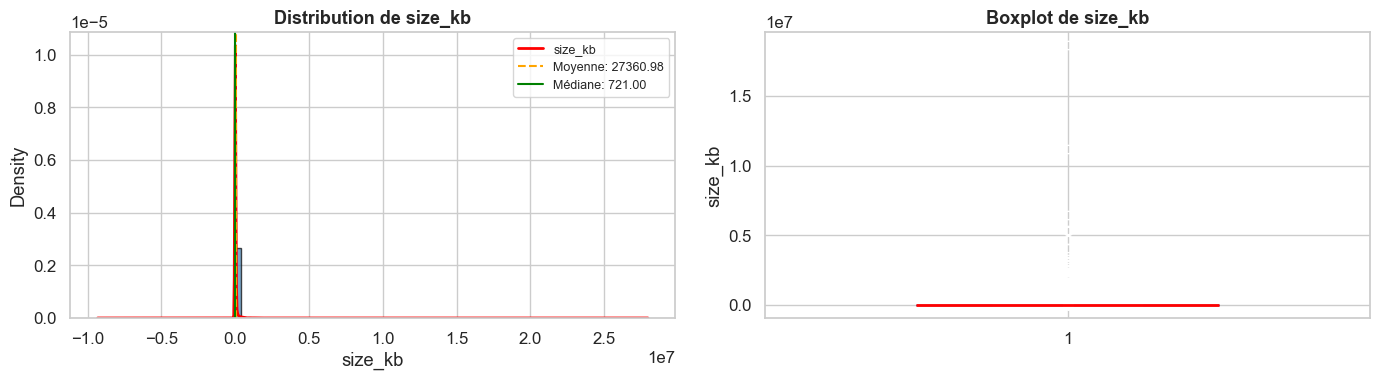

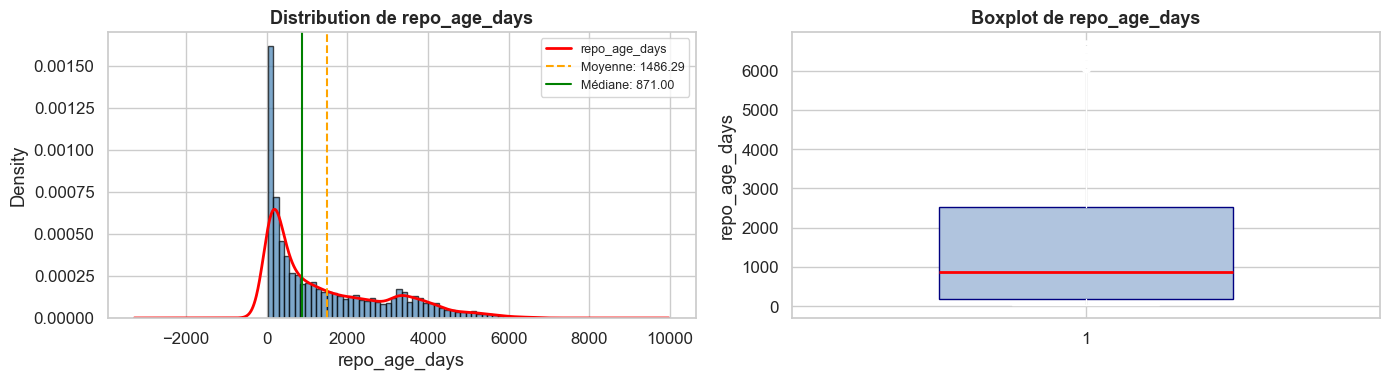

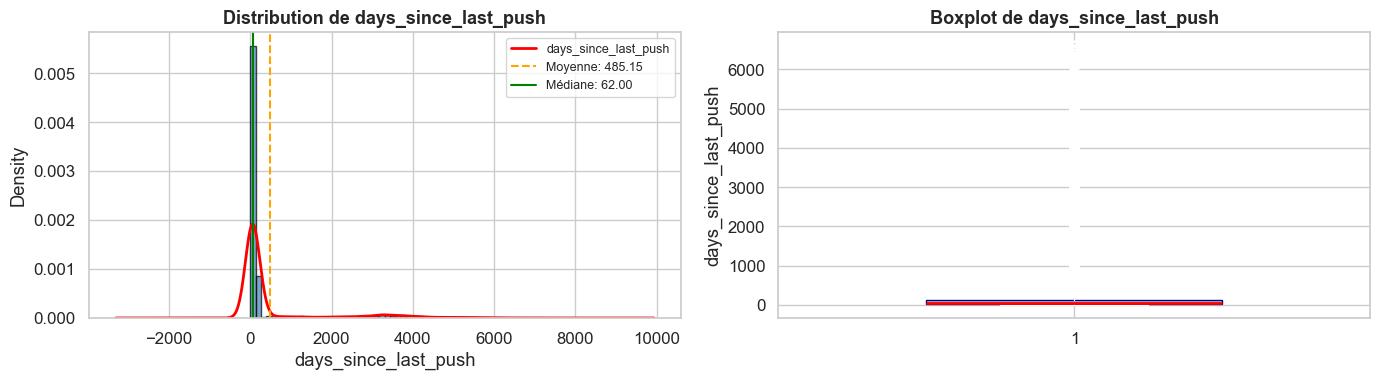

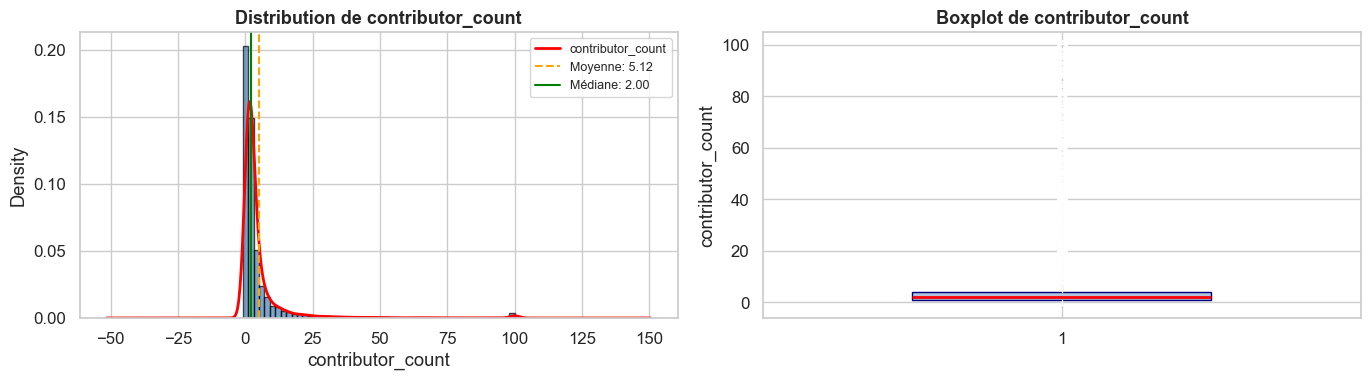

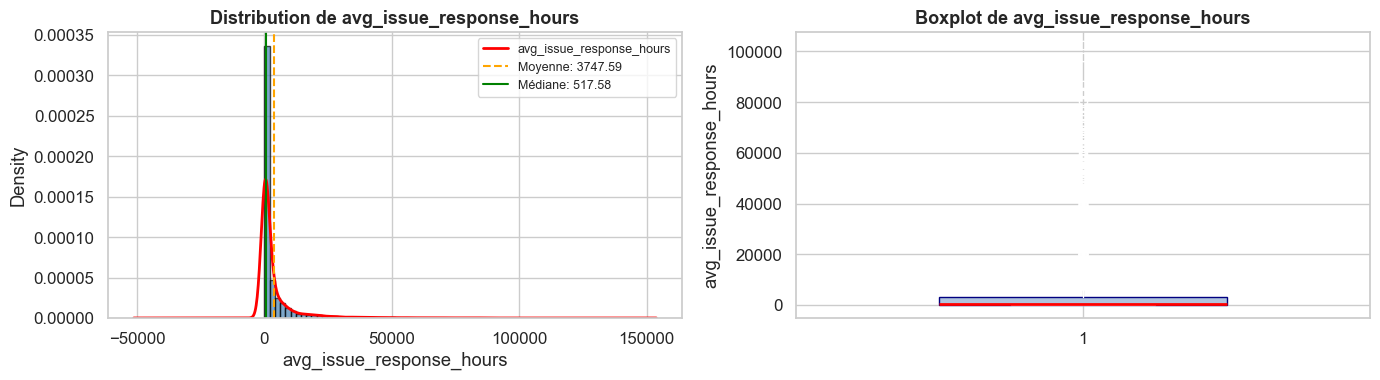

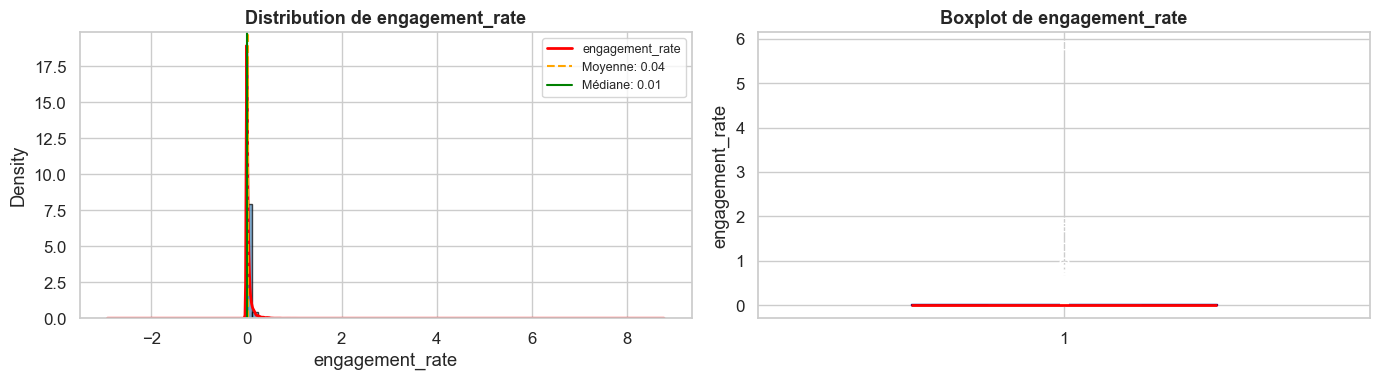

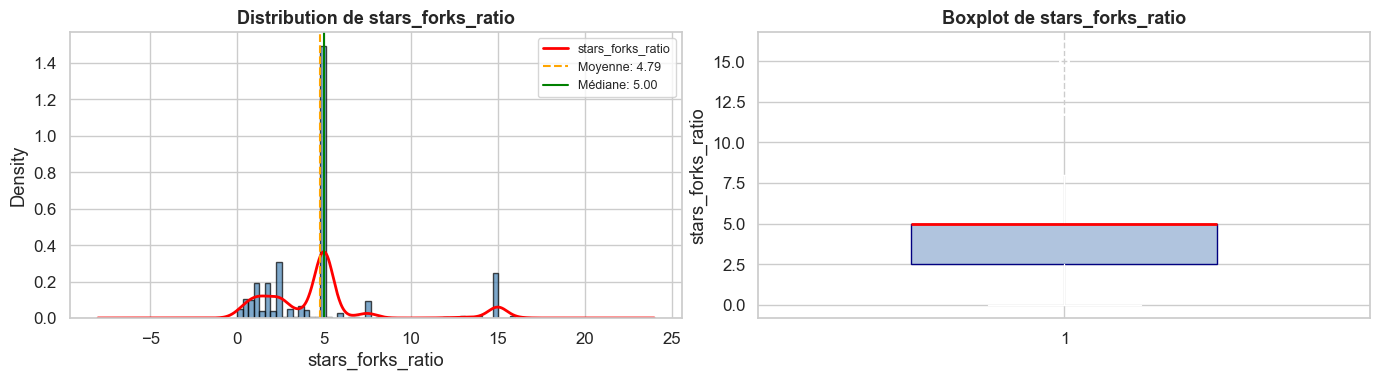

In [10]:
# %%
# Histogrammes et boxplots pour chaque variable numérique
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    # Histogramme + KDE
    data = df[col].dropna()
    data_clean = data[data >= 0] if col == 'avg_issue_response_hours' else data
    axes[0].hist(data_clean, bins=50, edgecolor='black', alpha=0.7, color='steelblue', density=True)
    if len(data_clean) > 1:
        try:
            data_clean.plot.kde(ax=axes[0], color='red', linewidth=2)
        except Exception:
            pass
    axes[0].axvline(data_clean.mean(), color='orange', linestyle='--', linewidth=1.5,
                    label=f'Moyenne: {data_clean.mean():.2f}')
    axes[0].axvline(data_clean.median(), color='green', linestyle='-', linewidth=1.5,
                    label=f'Médiane: {data_clean.median():.2f}')
    axes[0].set_title(f'Distribution de {col}', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=9)
    axes[0].set_xlabel(col)
    # Boxplot
    bp = axes[1].boxplot(data_clean, vert=True, widths=0.5, patch_artist=True,
                         boxprops=dict(facecolor='lightsteelblue', edgecolor='navy'),
                         medianprops=dict(color='red', linewidth=2))
    axes[1].set_title(f'Boxplot de {col}', fontsize=13, fontweight='bold')
    axes[1].set_ylabel(col)
    plt.tight_layout()
    plt.show()

%% [markdown]
**Observations :**
- La plupart des variables numériques présentent des distributions **très asymétriques** (right-skewed).
- De nombreux outliers sont visibles, notamment pour `stars`, `forks`, `size_kb`.
- `avg_issue_response_hours` contient des valeurs `-1.0` (code d'absence de données).
- La variable `engagement_rate` est concentrée près de 0 avec quelques valeurs extrêmes.

%% [markdown]
---
## 2. Exploration univariée — Variables catégorielles

Diagramme en barres des fréquences + identification des modalités < 1%.

In [11]:
# %%
# Analyse de la variable 'language'
print("=== LANGUAGE ===")
lang_counts = df['language'].value_counts()
lang_pct = df['language'].value_counts(normalize=True) * 100
lang_summary = pd.DataFrame({'Count': lang_counts, 'Percentage': lang_pct.round(2)})
print(lang_summary)
print(f"\nModalités avec < 1% : {lang_pct[lang_pct < 1].index.tolist()}")

=== LANGUAGE ===
            Count  Percentage
language                     
Java         1700       11.33
Ruby         1700       11.33
TypeScript   1700       11.33
Go           1699       11.33
Rust         1699       11.33
Python       1699       11.33
JavaScript   1698       11.32
C++          1698       11.32
PHP           975        6.50
C             424        2.83
Unknown         8        0.05

Modalités avec < 1% : ['Unknown']


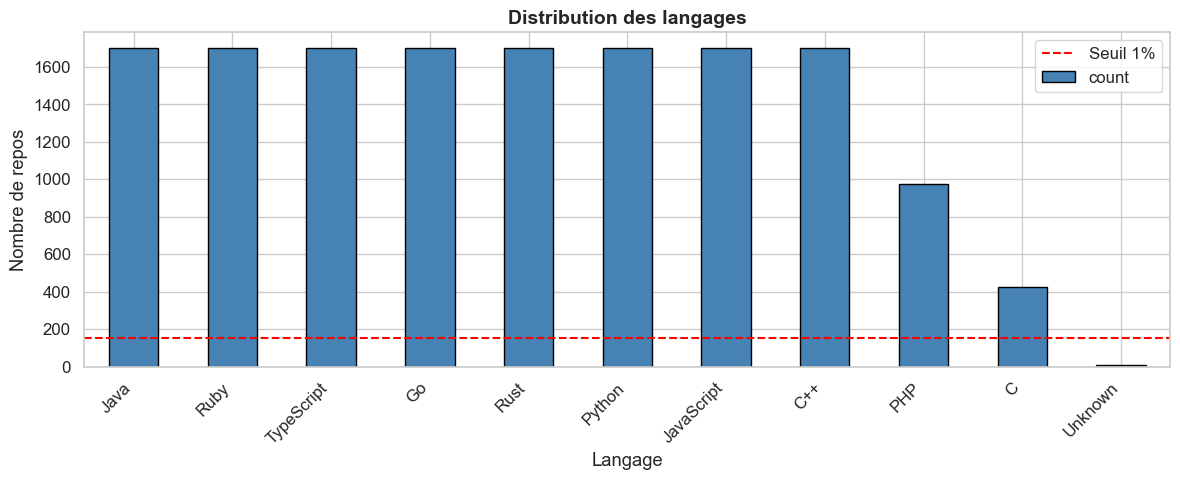

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
lang_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Distribution des langages', fontsize=14, fontweight='bold')
ax.set_xlabel('Langage')
ax.set_ylabel('Nombre de repos')
ax.axhline(y=len(df) * 0.01, color='red', linestyle='--', linewidth=1.5, label='Seuil 1%')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [13]:
# %%
# Analyse de la variable 'license'
print("=== LICENSE ===")
lic_counts = df['license'].value_counts()
lic_pct = df['license'].value_counts(normalize=True) * 100
lic_summary = pd.DataFrame({'Count': lic_counts, 'Percentage': lic_pct.round(2)})
print(lic_summary)
print(f"\nModalités avec < 1% : {lic_pct[lic_pct < 1].index.tolist()}")

=== LICENSE ===
                                                    Count  Percentage
license                                                              
MIT License                                          5073       51.77
Apache License 2.0                                   1639       16.72
Other                                                 969        9.89
GNU General Public License v3.0                       894        9.12
GNU Affero General Public License v3.0                270        2.76
GNU General Public License v2.0                       206        2.10
BSD 3-Clause "New" or "Revised" License               185        1.89
Mozilla Public License 2.0                            119        1.21
GNU Lesser General Public License v3.0                 88        0.90
The Unlicense                                          62        0.63
BSD 2-Clause "Simplified" License                      51        0.52
Creative Commons Zero v1.0 Universal                   45        0.46
GNU 

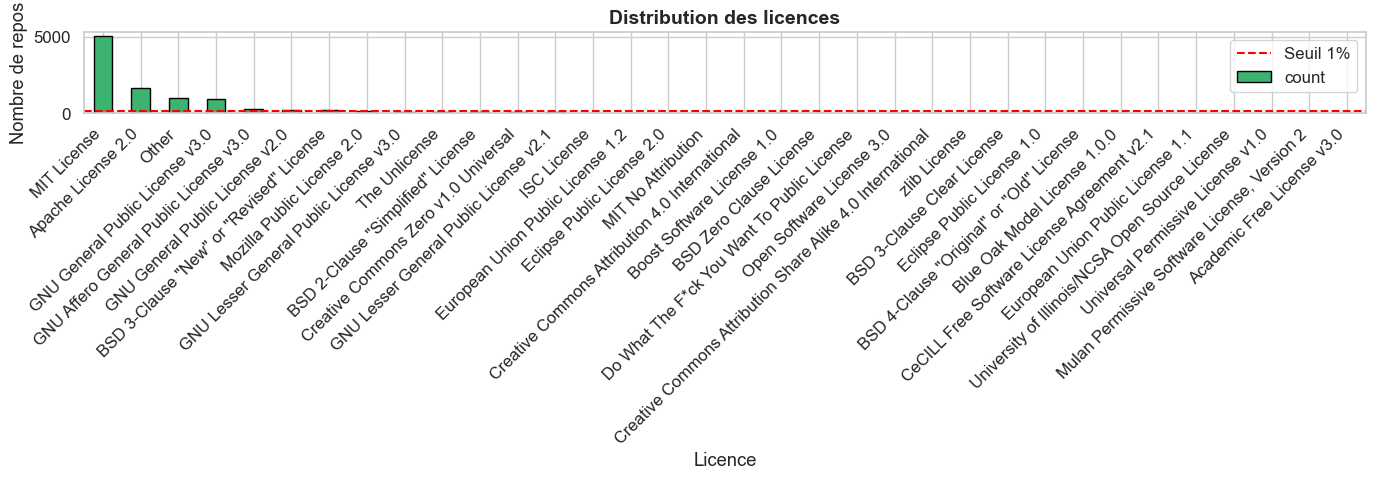

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))
lic_counts.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='black')
ax.set_title('Distribution des licences', fontsize=14, fontweight='bold')
ax.set_xlabel('Licence')
ax.set_ylabel('Nombre de repos')
ax.axhline(y=len(df) * 0.01, color='red', linestyle='--', linewidth=1.5, label='Seuil 1%')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

%% [markdown]
---
## 3. Exploration univariée — Variables binaires

Comptage et proportion de chaque valeur (0 vs 1).

In [15]:
# %%
# Comptage et proportions des variables binaires
binary_summary = pd.DataFrame()
for col in binary_cols:
    counts = df[col].value_counts()
    proportions = df[col].value_counts(normalize=True) * 100
    binary_summary[col] = pd.Series({
        'Count_0': counts.get(0, 0),
        'Count_1': counts.get(1, 0),
        '%_0': round(float(proportions.get(0, 0.0)), 2),
        '%_1': round(float(proportions.get(1, 0.0)), 2)
    })
print(binary_summary.T)

                 Count_0  Count_1     %_0    %_1
has_description   2566.0  12434.0   17.11  82.89
has_homepage     11543.0   3457.0   76.95  23.05
has_wiki          3560.0  11440.0   23.73  76.27
has_projects      1772.0  13228.0   11.81  88.19
is_fork          15000.0      0.0  100.00   0.00
archived         14560.0    440.0   97.07   2.93


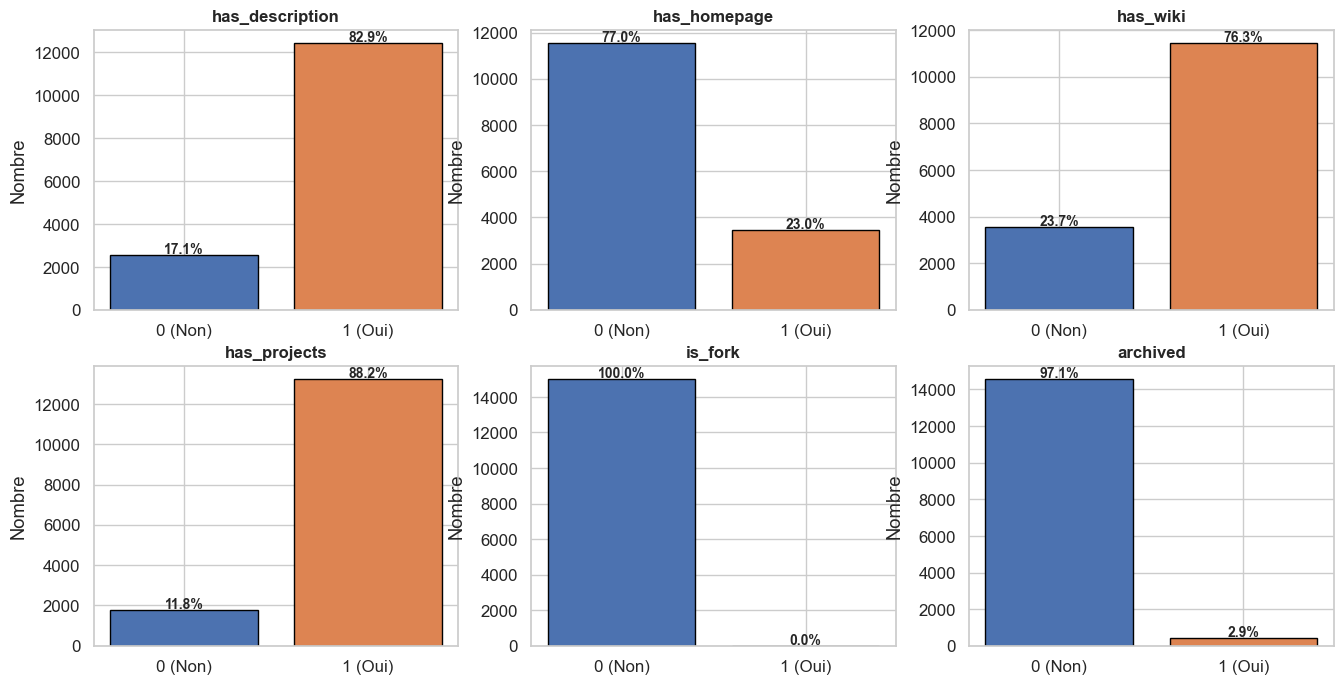

In [16]:
# %%
# Visualisation des variables binaires
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
colors = ['#4C72B0', '#DD8452']
for i, col in enumerate(binary_cols):
    counts = df[col].value_counts()
    axes[i].bar(['0 (Non)', '1 (Oui)'], [counts.get(0, 0), counts.get(1, 0)],
                color=colors, edgecolor='black')
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Nombre')
    # Ajouter les proportions
    total = len(df)
    for j, v in enumerate([counts.get(0, 0), counts.get(1, 0)]):
        axes[i].text(j, v + total*0.005, f'{v/total*100:.1f}%', ha='center', fontsize=10, fontweight='bold')

In [17]:
plt.suptitle('Distribution des variables binaires', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<Figure size 1400x600 with 0 Axes>

%% [markdown]
---
## 4. Exploration bivariée — Variables numériques × is_inactive

Boxplots par classe pour visualiser la séparation des distributions.

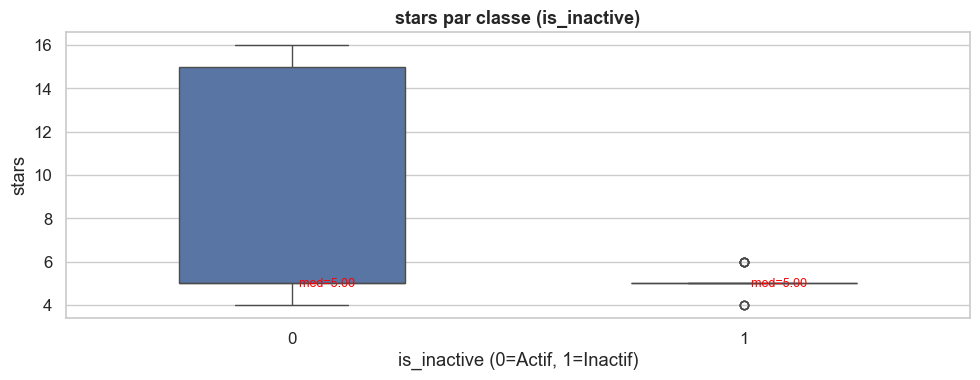

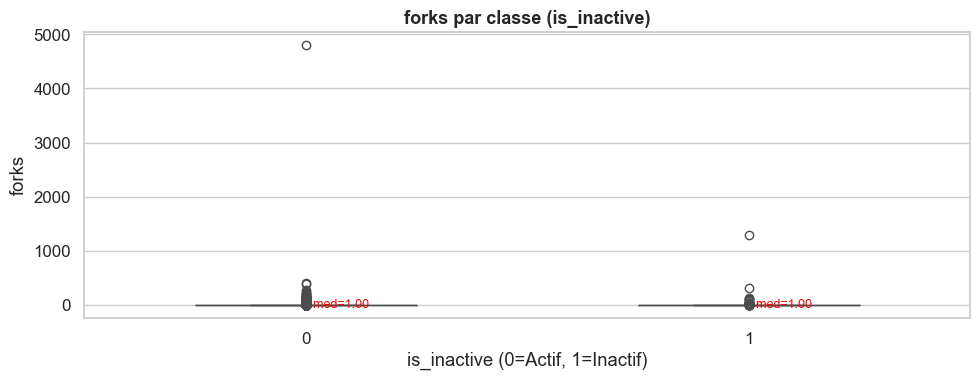

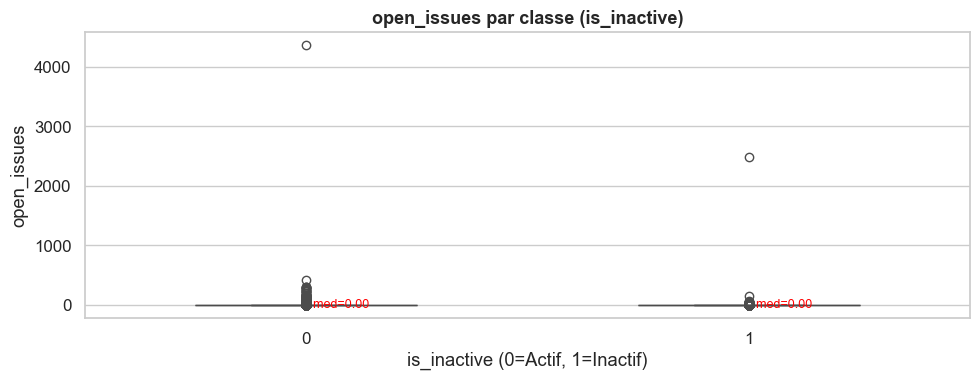

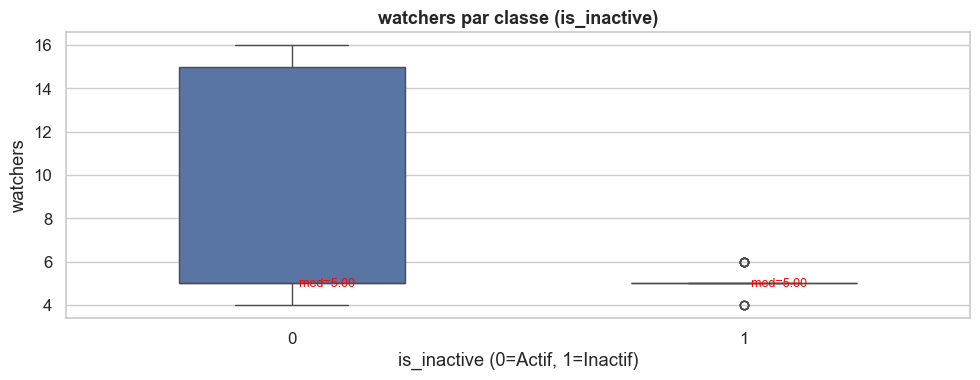

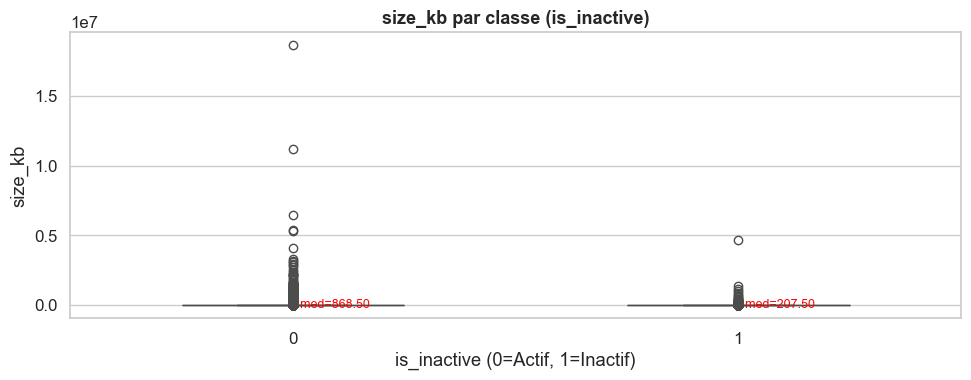

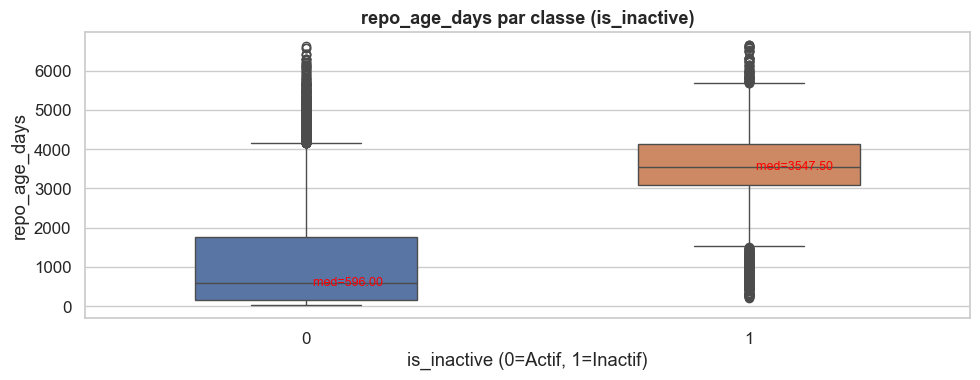

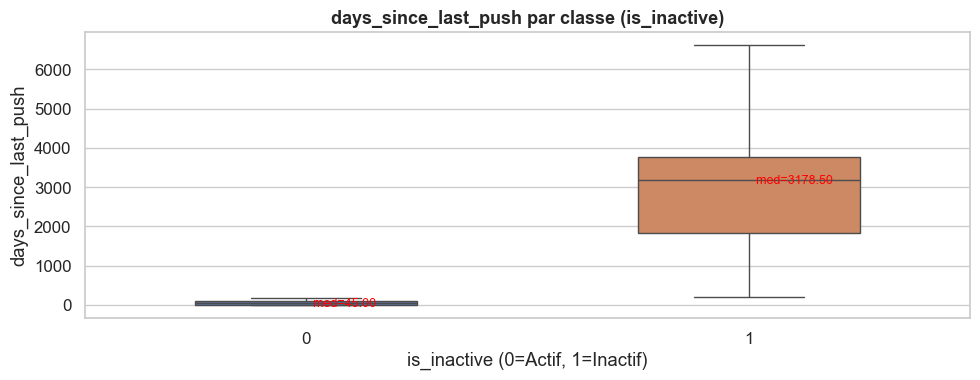

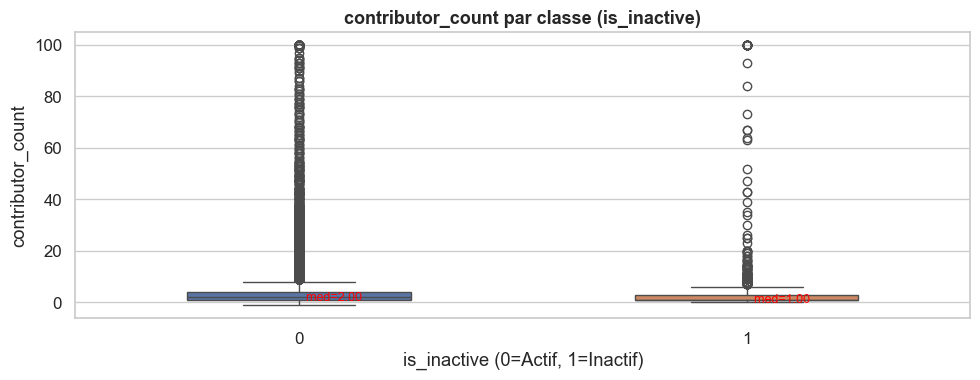

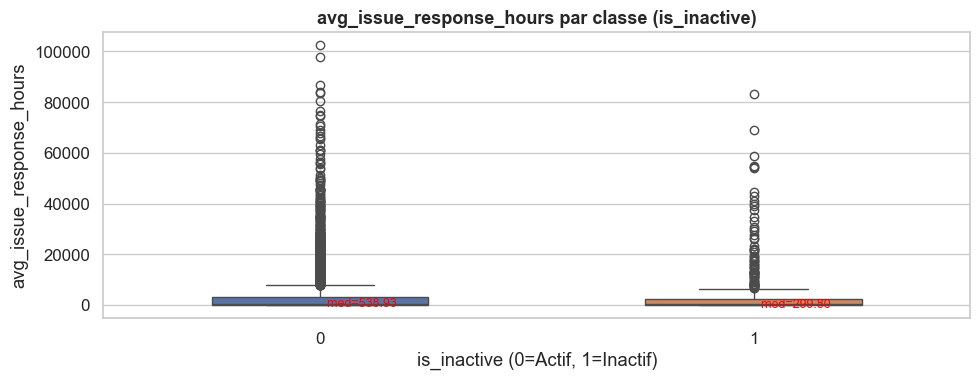

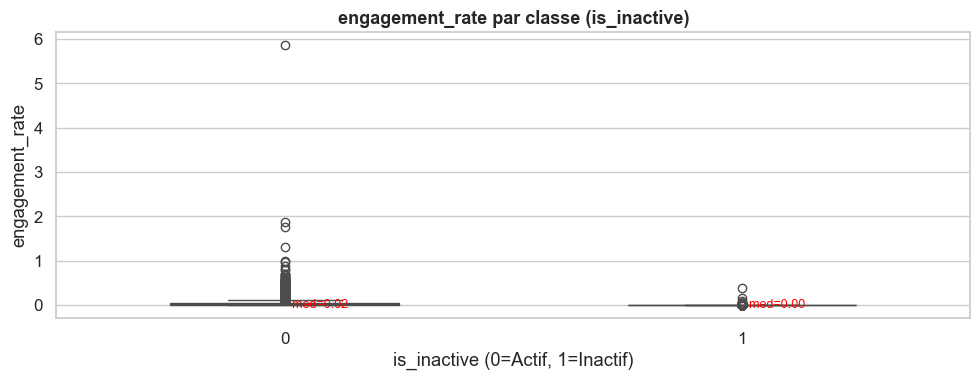

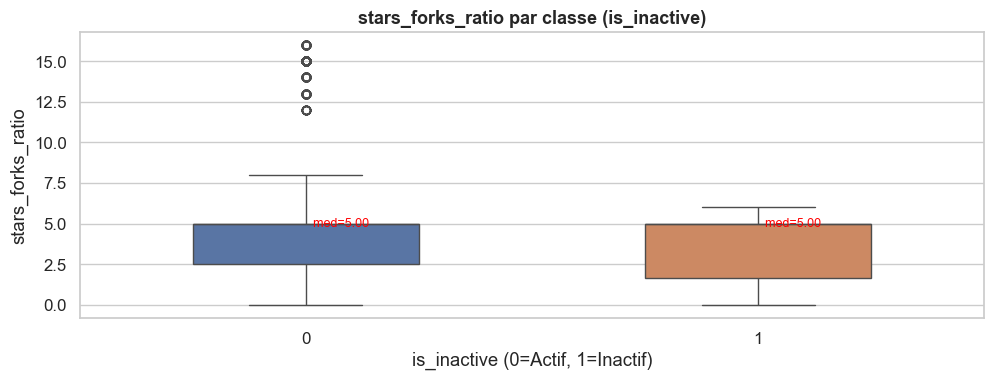

In [18]:
# %%
# Boxplots de chaque variable numérique par classe is_inactive
for col in numeric_cols:
    fig, ax = plt.subplots(figsize=(10, 4))
    data = df.copy()
    if col == 'avg_issue_response_hours':
        data = data[data[col] >= 0]  # Exclure les -1.0 pour la visu
    sns.boxplot(x='is_inactive', y=col, data=data, ax=ax, palette=['#4C72B0', '#DD8452'],
                width=0.5, showfliers=True)
    ax.set_title(f'{col} par classe (is_inactive)', fontsize=13, fontweight='bold')
    ax.set_xlabel('is_inactive (0=Actif, 1=Inactif)')
    ax.set_ylabel(col)
    # Afficher les médianes
    for cls in [0, 1]:
        median_val = data[data['is_inactive'] == cls][col].median()
        ax.text(cls, median_val, f'  med={median_val:.2f}', va='center', fontsize=9, color='red')
    plt.tight_layout()
    plt.show()

%% [markdown]
---
## 5. Exploration bivariée — Variables catégorielles × is_inactive

Tableau croisé + taux de is_inactive=1 par modalité.

In [19]:
# %%
# Language × is_inactive
print("=== Tableau croisé : language × is_inactive ===\n")
ct_lang = pd.crosstab(df['language'], df['is_inactive'], margins=True)
ct_lang['taux_inactive_%'] = (ct_lang[1] / ct_lang['All'] * 100).round(2)
print(ct_lang.sort_values('taux_inactive_%', ascending=False))

=== Tableau croisé : language × is_inactive ===

is_inactive      0     1    All  taux_inactive_%
language                                        
C              199   225    424            53.07
Unknown          6     2      8            25.00
PHP            750   225    975            23.08
All          12750  2250  15000            15.00
C++           1473   225   1698            13.25
JavaScript    1473   225   1698            13.25
Ruby          1475   225   1700            13.24
Java          1475   225   1700            13.24
TypeScript    1475   225   1700            13.24
Python        1474   225   1699            13.24
Go            1475   224   1699            13.18
Rust          1475   224   1699            13.18


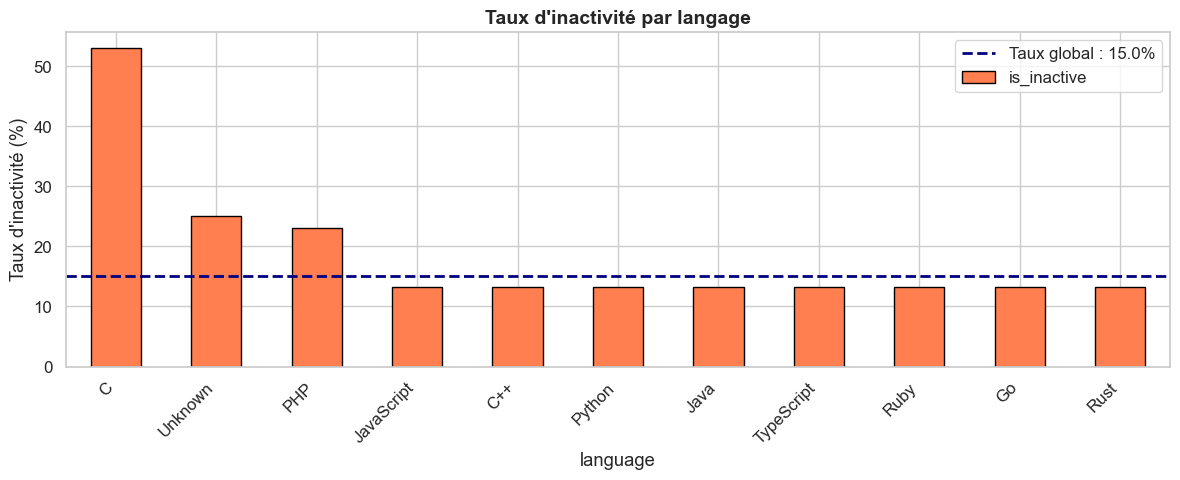

In [20]:
# Visualisation
fig, ax = plt.subplots(figsize=(12, 5))
inactive_rate = df.groupby('language')['is_inactive'].mean().sort_values(ascending=False) * 100
inactive_rate.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
ax.axhline(y=df['is_inactive'].mean() * 100, color='navy', linestyle='--', linewidth=2,
           label=f'Taux global : {df["is_inactive"].mean()*100:.1f}%')
ax.set_title("Taux d'inactivité par langage", fontsize=14, fontweight='bold')
ax.set_ylabel("Taux d'inactivité (%)")
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [21]:
# %%
# License × is_inactive
print("=== Tableau croisé : license × is_inactive ===\n")
ct_lic = pd.crosstab(df['license'], df['is_inactive'], margins=True)
ct_lic['taux_inactive_%'] = (ct_lic[1] / ct_lic['All'] * 100).round(2)
print(ct_lic.sort_values('taux_inactive_%', ascending=False))

=== Tableau croisé : license × is_inactive ===

is_inactive                                            0     1   All  \
license                                                                
CeCILL Free Software License Agreement v2.1            0     1     1   
Mulan Permissive Software License, Version 2           0     1     1   
Eclipse Public License 1.0                             2     1     3   
GNU General Public License v2.0                      148    58   206   
BSD 2-Clause "Simplified" License                     40    11    51   
The Unlicense                                         49    13    62   
GNU Lesser General Public License v3.0                74    14    88   
Creative Commons Attribution Share Alike 4.0 In...     6     1     7   
Other                                                844   125   969   
Open Software License 3.0                              7     1     8   
ISC License                                           28     4    32   
BSD 3-Clause "Ne

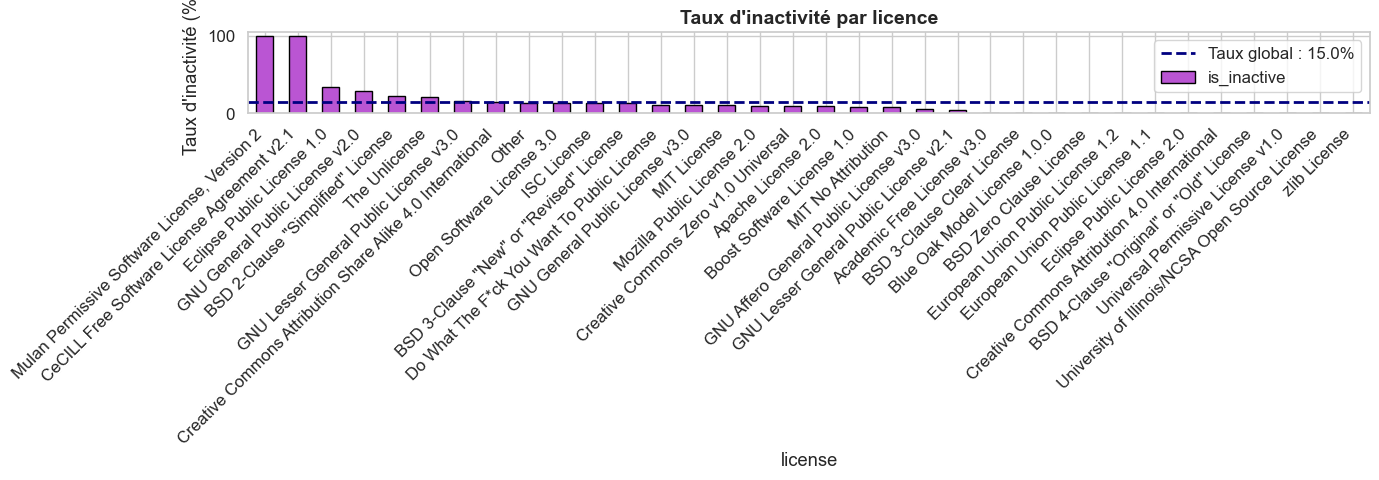

In [22]:
# Visualisation
fig, ax = plt.subplots(figsize=(14, 5))
inactive_rate_lic = df.groupby('license')['is_inactive'].mean().sort_values(ascending=False) * 100
inactive_rate_lic.plot(kind='bar', ax=ax, color='mediumorchid', edgecolor='black')
ax.axhline(y=df['is_inactive'].mean() * 100, color='navy', linestyle='--', linewidth=2,
           label=f'Taux global : {df["is_inactive"].mean()*100:.1f}%')
ax.set_title("Taux d'inactivité par licence", fontsize=14, fontweight='bold')
ax.set_ylabel("Taux d'inactivité (%)")
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

%% [markdown]
---
## 6. Matrice de corrélation

Heatmap entre toutes les variables numériques. Identification des paires avec |r| > 0.7.

In [23]:
# %%
# Matrice de corrélation
corr_matrix = df[numeric_cols].corr()

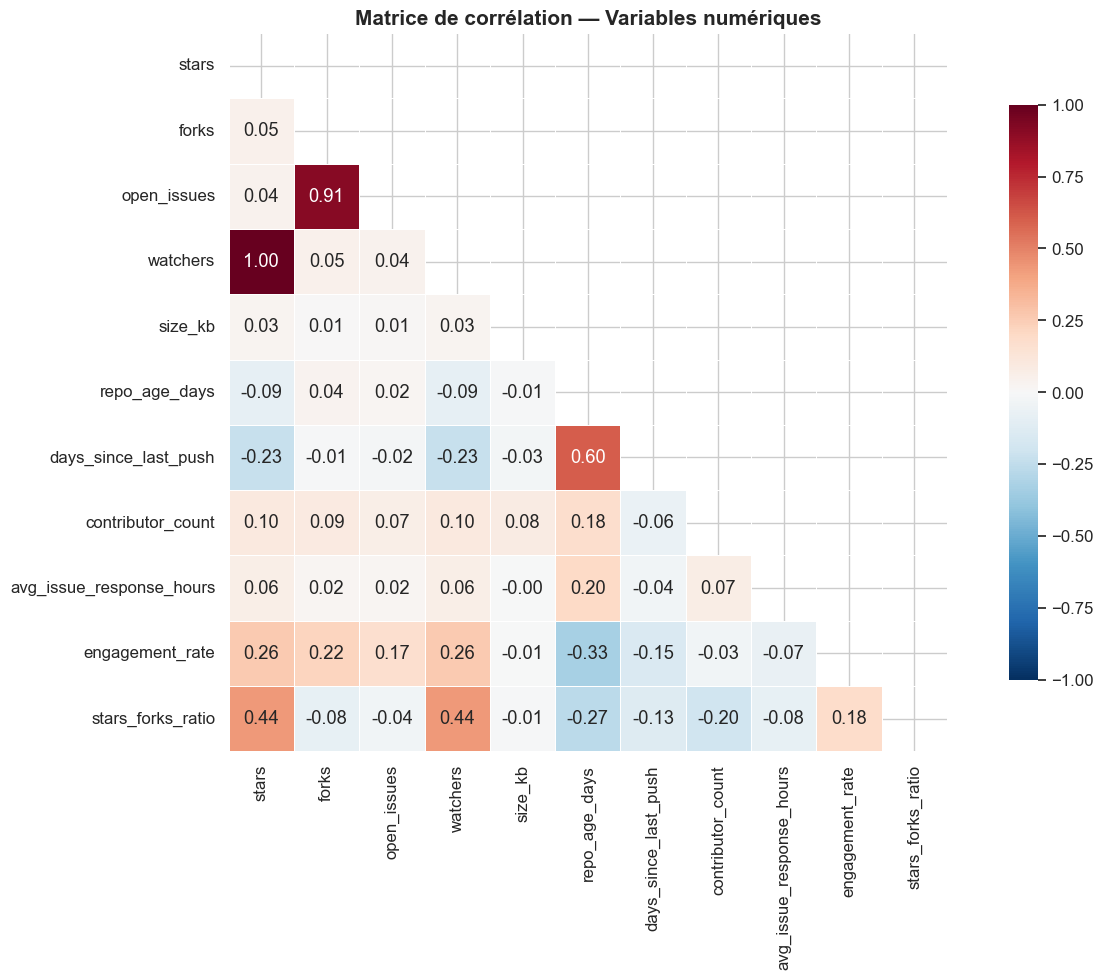

In [24]:
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Matrice de corrélation — Variables numériques', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
# %%
# Identification des paires fortement corrélées (|r| > 0.7)
print("=== Paires corrélées (|r| > 0.7) ===\n")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append({
                'Variable 1': corr_matrix.columns[i],
                'Variable 2': corr_matrix.columns[j],
                'r': round(r, 3)
            })

=== Paires corrélées (|r| > 0.7) ===



In [26]:
if high_corr:
    high_corr_df = pd.DataFrame(high_corr).sort_values('r', key=abs, ascending=False)
    print(high_corr_df.to_string(index=False))
else:
    print("Aucune paire avec |r| > 0.7")

Variable 1  Variable 2     r
     stars    watchers 1.000
     forks open_issues 0.907


%% [markdown]
---
## 7. Analyse spécifique du déséquilibre des classes

In [27]:
# %%
# Ratio exact des classes
class_counts = df['is_inactive'].value_counts()
class_pct = df['is_inactive'].value_counts(normalize=True) * 100
print("=== Distribution des classes ===")
print(f"Classe 0 (actif)   : {class_counts[0]:,} repos ({class_pct[0]:.2f}%)")
print(f"Classe 1 (inactif) : {class_counts[1]:,} repos ({class_pct[1]:.2f}%)")
print(f"\nRatio : 1 inactif pour {class_counts[0]/class_counts[1]:.2f} actifs")
print(f"Proportion minoritaire : {class_pct[1]:.2f}%")

=== Distribution des classes ===
Classe 0 (actif)   : 12,750 repos (85.00%)
Classe 1 (inactif) : 2,250 repos (15.00%)

Ratio : 1 inactif pour 5.67 actifs
Proportion minoritaire : 15.00%


Text(0, 0.5, 'Nombre de repos')

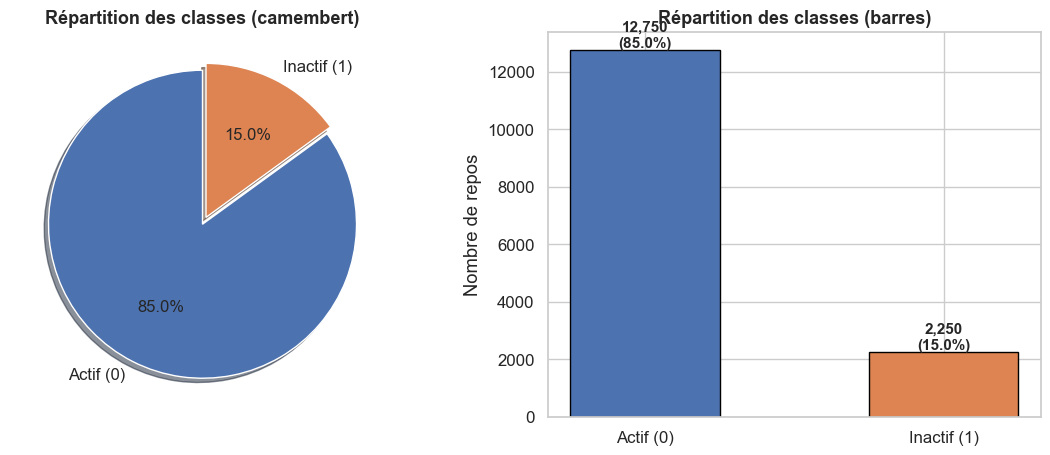

In [28]:
# %%
# Visualisation : Camembert + Barres
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Camembert
labels = ['Actif (0)', 'Inactif (1)']
sizes = [class_counts[0], class_counts[1]]
colors_pie = ['#4C72B0', '#DD8452']
explode = (0, 0.05)
axes[0].pie(sizes, explode=explode, labels=labels, colors=colors_pie, autopct='%1.1f%%',
            shadow=True, startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Répartition des classes (camembert)', fontsize=13, fontweight='bold')
# Diagramme en barres
axes[1].bar(labels, sizes, color=colors_pie, edgecolor='black', width=0.5)
for i, (lbl, cnt) in enumerate(zip(labels, sizes)):
    axes[1].text(i, cnt + 100, f'{cnt:,}\n({cnt/len(df)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Répartition des classes (barres)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Nombre de repos')

In [29]:
plt.tight_layout()
plt.show()

<Figure size 1400x600 with 0 Axes>

In [30]:
# %%
# Statistiques descriptives séparées par classe
print("=== Statistiques descriptives — Classe 0 (Actif) ===\n")
print(df[df['is_inactive'] == 0][numeric_cols].describe().round(2))

=== Statistiques descriptives — Classe 0 (Actif) ===

          stars     forks  open_issues  watchers      size_kb  repo_age_days  \
count  12750.00  12750.00     12750.00  12750.00     12750.00       12750.00   
mean       8.19      3.80         4.27      8.19     30172.78        1139.29   
std        4.64     43.77        41.13      4.64    252415.56        1266.29   
min        4.00      0.00         0.00      4.00         0.00          30.00   
25%        5.00      0.00         0.00      5.00       170.00         161.00   
50%        5.00      1.00         0.00      5.00       868.50         596.00   
75%       15.00      3.00         3.00     15.00      6535.25        1756.00   
max       16.00   4802.00      4365.00     16.00  18648336.00        6638.00   

       days_since_last_push  contributor_count  avg_issue_response_hours  \
count              12750.00           12750.00                  12750.00   
mean                  59.07               5.43                   1250.01 

In [31]:
print("\n=== Statistiques descriptives — Classe 1 (Inactif) ===\n")
print(df[df['is_inactive'] == 1][numeric_cols].describe().round(2))


=== Statistiques descriptives — Classe 1 (Inactif) ===

         stars    forks  open_issues  watchers     size_kb  repo_age_days  \
count  2250.00  2250.00      2250.00   2250.00     2250.00        2250.00   
mean      5.00     2.99         2.56      5.00    11427.45        3452.62   
std       0.07    28.50        52.78      0.07   115063.50        1274.94   
min       4.00     0.00         0.00      4.00        0.00         211.00   
25%       5.00     0.00         0.00      5.00       55.00        3083.25   
50%       5.00     1.00         0.00      5.00      207.50        3547.50   
75%       5.00     3.00         1.00      5.00     1774.25        4122.00   
max       6.00  1289.00      2492.00      6.00  4681430.00        6656.00   

       days_since_last_push  contributor_count  avg_issue_response_hours  \
count               2250.00            2250.00                   2250.00   
mean                2899.60               3.31                    821.94   
std                 1

In [32]:
# %%
# Identification des "features signaux" — différences significatives entre classes
print("=== Features signaux (Mann-Whitney U test) ===\n")
signal_features = []
for col in numeric_cols:
    active = df[df['is_inactive'] == 0][col].dropna()
    inactive = df[df['is_inactive'] == 1][col].dropna()
    
    # Exclure les -1.0 de avg_issue_response_hours
    if col == 'avg_issue_response_hours':
        active = active[active >= 0]
        inactive = inactive[inactive >= 0]
    
    stat, pval = stats.mannwhitneyu(active, inactive, alternative='two-sided')
    mean_diff = abs(active.mean() - inactive.mean())
    median_diff = abs(active.median() - inactive.median())
    
    signal_features.append({
        'Variable': col,
        'Médiane_Actif': active.median(),
        'Médiane_Inactif': inactive.median(),
        'Diff_médiane': median_diff,
        'p-value': pval,
        'Significatif': '✅' if pval < 0.001 else ('⚠️' if pval < 0.05 else '❌')
    })

=== Features signaux (Mann-Whitney U test) ===



In [33]:
signal_df = pd.DataFrame(signal_features)
signal_df = signal_df.sort_values('p-value')
print(signal_df.to_string(index=False))

                Variable  Médiane_Actif  Médiane_Inactif  Diff_médiane       p-value Significatif
    days_since_last_push        45.0000        3178.5000     3133.5000  0.000000e+00            ✅
           repo_age_days       596.0000        3547.5000     2951.5000  0.000000e+00            ✅
         engagement_rate         0.0163           0.0019        0.0144  0.000000e+00            ✅
                   stars         5.0000           5.0000        0.0000 1.847781e-185            ✅
                watchers         5.0000           5.0000        0.0000 1.847781e-185            ✅
                 size_kb       868.5000         207.5000      661.0000  1.918106e-98            ✅
       contributor_count         2.0000           1.0000        1.0000  2.576279e-61            ✅
             open_issues         0.0000           0.0000        0.0000  1.327096e-49            ✅
       stars_forks_ratio         5.0000           5.0000        0.0000  2.521168e-36            ✅
avg_issue_response_h

%% [markdown]
---
## 8. Synthèse des observations

### Résumé des observations clés

1. **Distributions asymétriques** : Toutes les variables numériques sont fortement right-skewed
   avec de nombreux outliers → le `RobustScaler` sera le choix approprié pour la normalisation.

2. **Variable sentinelle** : `avg_issue_response_hours = -1.0` est un code d'absence de données
   (repos sans issues fermées). À traiter comme valeur manquante en Phase 2.

3. **Déséquilibre des classes** : ~85% actifs vs ~15% inactifs. Ratio ~5.7:1.
   Ce déséquilibre modéré nécessitera des stratégies spécifiques (SMOTE, class_weight, etc.).

4. **Features les plus prometteuses** (séparation nette entre classes) :
   - `days_since_last_push` — ATTENTION : variable de leakage, sera retirée du modèle.
   - `contributor_count` — les repos inactifs ont significativement moins de contributeurs.
   - `engagement_rate` — les repos inactifs ont un taux d'engagement beaucoup plus faible.
   - `stars`, `forks`, `watchers` — les repos inactifs ont des valeurs nettement plus basses.
   - `archived` — ATTENTION : leakage, sera retiré.

5. **Corrélations fortes** : `stars` ↔ `watchers` (très forte), `stars` ↔ `forks` (forte).
   L'`engagement_rate` est aussi liée à `stars` et `forks` par construction.

6. **Variables catégorielles** : Certains langages/licences ont des taux d'inactivité
   significativement différents du taux global, confirmant leur utilité comme features.

### Features à surveiller pour le preprocessing
- Regrouper les modalités rares (< 1%) de `language` et `license` en "Other".
- Imputer `avg_issue_response_hours = -1.0` → NaN → médiane.
- Appliquer `RobustScaler` à cause des outliers massifs.

%%